<a href="https://colab.research.google.com/github/AnuragKamblekar/Interncodes/blob/main/SupervisedAi23/4/2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

By Using XGBoost
Loading sensors...
Engineering features...

=== Accelerometer XGBoost ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       113
           1       0.96      0.94      0.95      1059
           2       0.98      0.98      0.98      2522

    accuracy                           0.97      3694
   macro avg       0.96      0.96      0.96      3694
weighted avg       0.97      0.97      0.97      3694



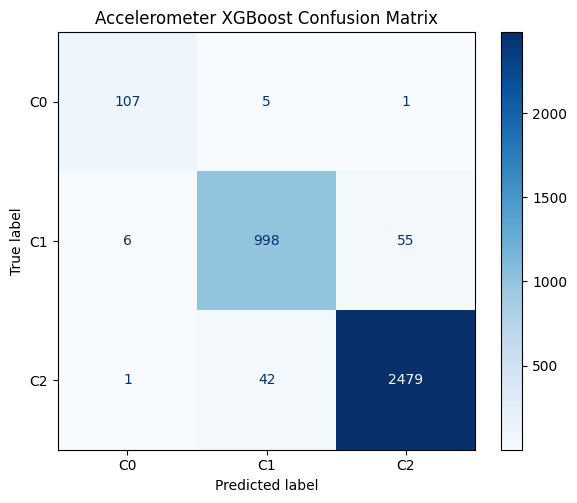

Top features (XGBoost):
acc_mag_roll_mean    0.219578
acc_dx               0.192030
acc_z                0.170767
acc_dz               0.108343
acc_mag_roll_std     0.094835
acc_x                0.080903
acc_mag              0.059215
acc_dy               0.055365
acc_y                0.018964

Regression metrics for ACC:
  Predict acc_x from ['acc_y', 'acc_z']: MSE=2.05991, RMSE=1.43524, R²=0.0927074
  Predict acc_y from ['acc_x', 'acc_z']: MSE=2.1993, RMSE=1.483, R²=0.0485133
  Predict acc_z from ['acc_x', 'acc_y']: MSE=3.2423, RMSE=1.80064, R²=0.0613376
  Predict acc_mag from ['acc_x', 'acc_y', 'acc_z']: MSE=3.2353, RMSE=1.79869, R²=0.00890913

=== Gyroscope XGBoost ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       273
           1       1.00      1.00      1.00      3419
           2       0.60      0.75      0.67         4

    accuracy                           1.00      3696
   macro avg       0.86      0.90      0.88    

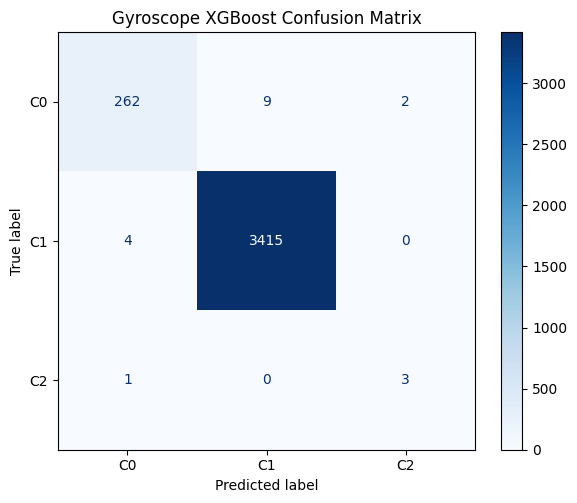

Top features (XGBoost):
gyro_mag_roll_mean    0.727408
gyro_mag              0.132905
gyro_mag_roll_std     0.087623
gyro_z                0.020149
gyro_x                0.010209
gyro_dy               0.006908
gyro_y                0.006045
gyro_dx               0.004442
gyro_dz               0.004310

Regression metrics for GYRO:
  Predict gyro_x from ['gyro_y', 'gyro_z']: MSE=0.06921, RMSE=0.263078, R²=0.0657449
  Predict gyro_y from ['gyro_x', 'gyro_z']: MSE=0.116468, RMSE=0.341274, R²=0.00667448
  Predict gyro_z from ['gyro_x', 'gyro_y']: MSE=0.0405482, RMSE=0.201366, R²=0.0743374
  Predict gyro_mag from ['gyro_x', 'gyro_y', 'gyro_z']: MSE=0.106503, RMSE=0.326348, R²=0.0385409

=== Magnetometer XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       348
           1       1.00      1.00      1.00      1623
           2       1.00      1.00      1.00         3

    accuracy                           1.00      1974
   macro

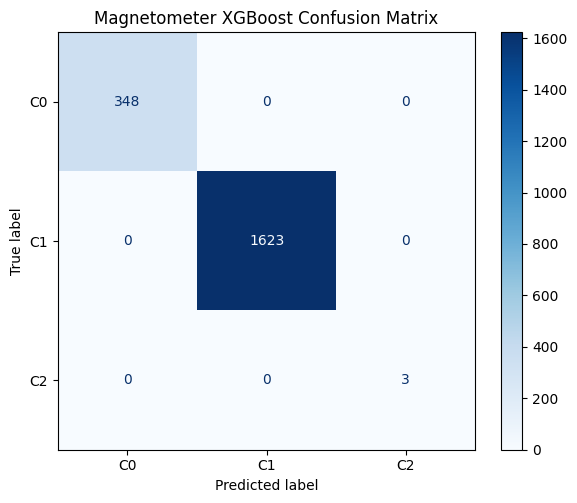

Top features (XGBoost):
mag_x                0.912673
mag_dz               0.024943
mag_mag_roll_std     0.022012
mag_dx               0.014597
mag_mag              0.012230
mag_z                0.007052
mag_y                0.003217
mag_mag_roll_mean    0.001841
mag_dy               0.001435

Regression metrics for MAG:
  Predict mag_x from ['mag_y', 'mag_z']: MSE=141.779, RMSE=11.9071, R²=0.640169
  Predict mag_y from ['mag_x', 'mag_z']: MSE=94.0549, RMSE=9.69819, R²=0.597107
  Predict mag_z from ['mag_x', 'mag_y']: MSE=47.7314, RMSE=6.90879, R²=0.441352
  Predict mag_mag from ['mag_x', 'mag_y', 'mag_z']: MSE=27.6062, RMSE=5.25416, R²=0.29955

=== TotalAcceleration XGBoost ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2475
           1       0.94      0.90      0.92       224
           2       0.98      0.98      0.98      1969

    accuracy                           0.98      4668
   macro avg       0.97      0.95      0

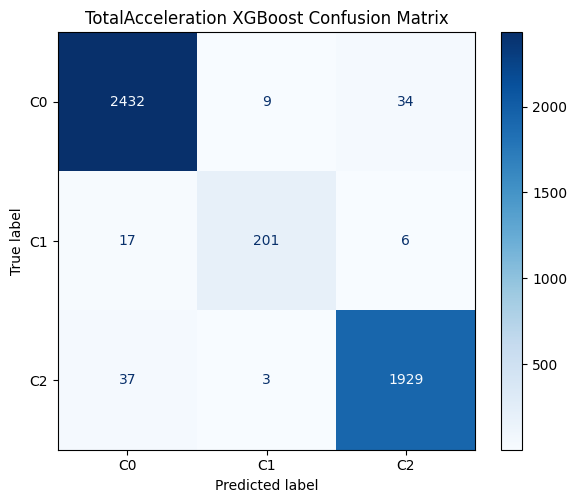

Top features (XGBoost):
totacc_z                0.475089
totacc_mag              0.172187
totacc_dz               0.086995
totacc_mag_roll_mean    0.066942
totacc_mag_roll_std     0.063036
totacc_dx               0.056007
totacc_dy               0.045446
totacc_y                0.017381
totacc_x                0.016916

Regression metrics for TOTACC:
  Predict totacc_x from ['totacc_y', 'totacc_z']: MSE=2.14635, RMSE=1.46504, R²=0.00189687
  Predict totacc_y from ['totacc_x', 'totacc_z']: MSE=3.88577, RMSE=1.97123, R²=0.029079
  Predict totacc_z from ['totacc_x', 'totacc_y']: MSE=3.27512, RMSE=1.80973, R²=0.0291413
  Predict totacc_mag from ['totacc_x', 'totacc_y', 'totacc_z']: MSE=0.620932, RMSE=0.787993, R²=0.788481

Saved xgboost_metrics_summary.csv


In [77]:
print("By Using XGBoost")
# Colab cell: Train and evaluate XGBoost per sensor using KMeans labels as supervised targets
# Includes regression metrics (MSE, RMSE, R²) per sensor: per-axis and magnitude regressions.
# Run this cell after uploading Accelerometer.csv, Gyroscope.csv, Magnetometer.csv, TotalAcceleration.csv

# Install XGBoost (run once)
!pip install -q xgboost

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score,
                             mean_squared_error, r2_score)
from sklearn.linear_model import LinearRegression
import xgboost as xgb

# ---------- User files ----------
acc_file = "Accelerometer.csv"
gyro_file = "Gyroscope.csv"
mag_file = "Magnetometer.csv"
totacc_file = "TotalAcceleration.csv"

# ---------- Utilities ----------
def normalize_axes(df, prefix):
    mapping = {}
    for c in df.columns:
        lc = c.strip().lower()
        if lc in ['x','accx','acc_x','accel_x','gyro_x','mag_x','totacc_x']:
            mapping[c] = f"{prefix}_x"
        elif lc in ['y','accy','acc_y','accel_y','gyro_y','mag_y','totacc_y']:
            mapping[c] = f"{prefix}_y"
        elif lc in ['z','accz','acc_z','accel_z','gyro_z','mag_z','totacc_z']:
            mapping[c] = f"{prefix}_z"
        elif 'second' in lc or 'time' in lc:
            mapping[c] = 'seconds_elapsed'
    return df.rename(columns=mapping)

def load_sensor(filename, prefix):
    df = pd.read_csv(filename, low_memory=False)
    df = normalize_axes(df, prefix)
    required = [f"{prefix}_x", f"{prefix}_y", f"{prefix}_z"]
    if not all(c in df.columns for c in required):
        raise ValueError(f"Missing x,y,z for {prefix} in {filename}. Found: {df.columns.tolist()}")
    df = df[required + (['seconds_elapsed'] if 'seconds_elapsed' in df.columns else [])].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna(subset=required).reset_index(drop=True)
    return df

def engineer_features(df, prefix, roll_window=10):
    x = df[f"{prefix}_x"]; y = df[f"{prefix}_y"]; z = df[f"{prefix}_z"]
    feat = pd.DataFrame({
        f"{prefix}_x": x, f"{prefix}_y": y, f"{prefix}_z": z,
        f"{prefix}_mag": np.sqrt(x**2 + y**2 + z**2)
    })
    feat[f"{prefix}_mag_roll_mean"] = feat[f"{prefix}_mag"].rolling(window=roll_window, min_periods=1).mean()
    feat[f"{prefix}_mag_roll_std"] = feat[f"{prefix}_mag"].rolling(window=roll_window, min_periods=1).std().fillna(0)
    feat[f"{prefix}_dx"] = x.diff().fillna(0)
    feat[f"{prefix}_dy"] = y.diff().fillna(0)
    feat[f"{prefix}_dz"] = z.diff().fillna(0)
    return feat.fillna(0)

def make_kmeans_labels(X_df, n_clusters=3, random_state=42):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_df)
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = km.fit_predict(Xs)
    return labels, scaler, km

def print_regression_metrics(X_df, prefix):
    """
    For sensor prefix (e.g., 'acc'), compute:
      - For each axis: predict axis from the other two (LinearRegression) -> MSE, RMSE, R2
      - Predict magnitude from x,y,z -> MSE, RMSE, R2
    """
    print(f"\nRegression metrics for {prefix.upper()}:")
    axes = [f"{prefix}_x", f"{prefix}_y", f"{prefix}_z"]
    for i, axis in enumerate(axes):
        if axis not in X_df.columns:
            continue
        predictors = [a for a in axes if a != axis and a in X_df.columns]
        if not predictors:
            continue
        X = X_df[predictors].values
        y = X_df[axis].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        reg = LinearRegression().fit(X_train, y_train)
        y_pred = reg.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        print(f"  Predict {axis} from {predictors}: MSE={mse:.6g}, RMSE={rmse:.6g}, R²={r2:.6g}")

    mag_col = [c for c in X_df.columns if f"{prefix}_mag" in c]
    if mag_col:
        mag = X_df[mag_col[0]].values
        predictors = [c for c in X_df.columns if c in axes]
        X = X_df[predictors].values
        X_train, X_test, y_train, y_test = train_test_split(X, mag, test_size=0.2, random_state=42)
        reg = LinearRegression().fit(X_train, y_train)
        y_pred = reg.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        print(f"  Predict {mag_col[0]} from {predictors}: MSE={mse:.6g}, RMSE={rmse:.6g}, R²={r2:.6g}")

def train_xgboost(X, y, model_name="Model"):
    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    print(f"\n=== {model_name} XGBoost ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    labels = np.unique(np.concatenate([np.asarray(y_test).ravel(), np.asarray(y_pred).ravel()]))
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"C{int(l)}" for l in labels])
    fig, ax = plt.subplots(figsize=(6,5))
    disp.plot(cmap='Blues', ax=ax, colorbar=True)
    ax.set_title(f"{model_name} XGBoost Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # Feature importances
    try:
        fi = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
        print("Top features (XGBoost):")
        print(fi.head(10).to_string())
    except Exception:
        pass

    # Regression metrics for this sensor's features (per-axis and magnitude)
    # X is a DataFrame here; determine prefix from first column name (assumes consistent naming)
    first_col = X.columns[0]
    prefix = first_col.split('_')[0]
    print_regression_metrics(X, prefix)

    return {"clf": clf, "cm": cm, "report": classification_report(y_test, y_pred, output_dict=True, zero_division=0)}

# ---------- Run per sensor ----------
print("Loading sensors...")
acc_df = load_sensor(acc_file, "acc")
gyro_df = load_sensor(gyro_file, "gyro")
mag_df = load_sensor(mag_file, "mag")
totacc_df = load_sensor(totacc_file, "totacc")

print("Engineering features...")
acc_X = engineer_features(acc_df, "acc")
gyro_X = engineer_features(gyro_df, "gyro")
mag_X = engineer_features(mag_df, "mag")
totacc_X = engineer_features(totacc_df, "totacc")

results = {}

# Accelerometer
acc_labels, acc_scaler, acc_km = make_kmeans_labels(acc_X, n_clusters=3)
results['acc'] = train_xgboost(acc_X, acc_labels, model_name="Accelerometer")

# Gyroscope
gyro_labels, gyro_scaler, gyro_km = make_kmeans_labels(gyro_X, n_clusters=3)
results['gyro'] = train_xgboost(gyro_X, gyro_labels, model_name="Gyroscope")

# Magnetometer
mag_labels, mag_scaler, mag_km = make_kmeans_labels(mag_X, n_clusters=3)
results['mag'] = train_xgboost(mag_X, mag_labels, model_name="Magnetometer")

# TotalAcceleration
tot_labels, tot_scaler, tot_km = make_kmeans_labels(totacc_X, n_clusters=3)
results['totacc'] = train_xgboost(totacc_X, tot_labels, model_name="TotalAcceleration")

# Optionally save summary metrics
summary = []
for k,v in results.items():
    rep = v['report']
    summary.append({"sensor": k, "accuracy": rep.get("accuracy", None), "macro avg f1": rep.get("macro avg", {}).get("f1-score", None)})
pd.DataFrame(summary).to_csv("xgboost_metrics_summary.csv", index=False)
print("\nSaved xgboost_metrics_summary.csv")


Loading sensors...
Engineering features...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001459 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 14773, number of used features: 9
[LightGBM] [Info] Start training from score -3.489089
[LightGBM] [Info] Start training from score -1.249418
[LightGBM] [Info] Start training from score -0.381554
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

=== Accelerometer LightGBM ===
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       113
           1       0.95      0.94      0.95      1059
           2       0.98      0.98      0.98      2522

    accuracy                           0.97      3694
   macro avg       0.95      0.94      0.95      3694
weighted avg       0.97      0.97      0.97      3694



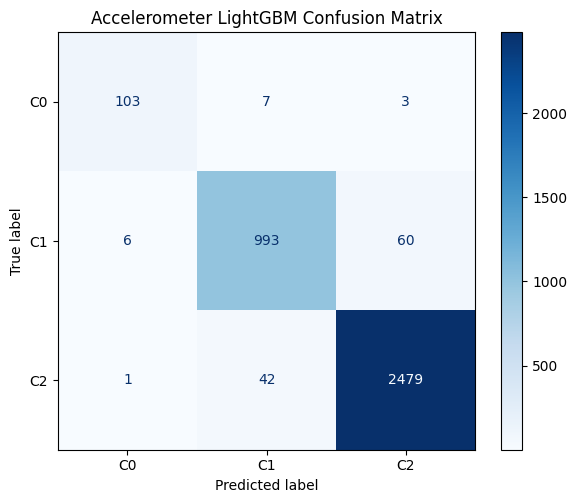

Top features (LightGBM):
acc_z                1299
acc_dx               1289
acc_mag_roll_std     1234
acc_dz               1204
acc_x                 959
acc_mag_roll_mean     876
acc_dy                812
acc_mag               745
acc_y                 574

Regression metrics for ACC:
  Predict acc_x from ['acc_y', 'acc_z']: MSE=2.05991, RMSE=1.43524, R²=0.0927074
  Predict acc_y from ['acc_x', 'acc_z']: MSE=2.1993, RMSE=1.483, R²=0.0485133
  Predict acc_z from ['acc_x', 'acc_y']: MSE=3.2423, RMSE=1.80064, R²=0.0613376
  Predict acc_mag from ['acc_x', 'acc_y', 'acc_z']: MSE=3.2353, RMSE=1.79869, R²=0.00890913
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011856 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 14782, number of used features: 9
[LightGBM] [Info] Start training from score -2.607233
[LightGBM] [Info] Start training from s

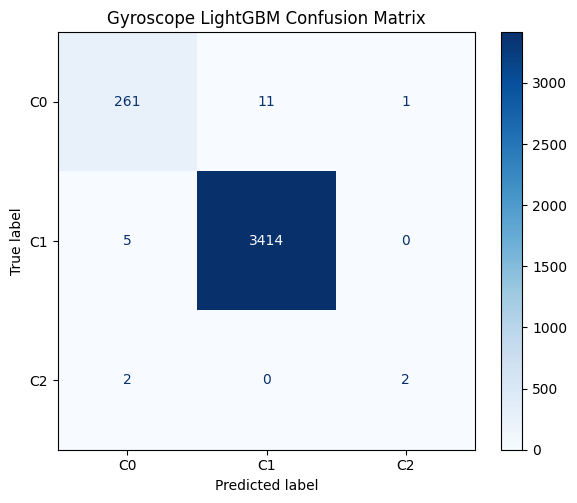

Top features (LightGBM):
gyro_mag_roll_std     1880
gyro_mag              1673
gyro_mag_roll_mean    1456
gyro_z                 752
gyro_x                 590
gyro_dy                569
gyro_y                 419
gyro_dx                363
gyro_dz                327

Regression metrics for GYRO:
  Predict gyro_x from ['gyro_y', 'gyro_z']: MSE=0.06921, RMSE=0.263078, R²=0.0657449
  Predict gyro_y from ['gyro_x', 'gyro_z']: MSE=0.116468, RMSE=0.341274, R²=0.00667448
  Predict gyro_z from ['gyro_x', 'gyro_y']: MSE=0.0405482, RMSE=0.201366, R²=0.0743374
  Predict gyro_mag from ['gyro_x', 'gyro_y', 'gyro_z']: MSE=0.106503, RMSE=0.326348, R²=0.0385409
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000873 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 7894, number of used features: 9
[LightGBM] [Info] Start training from score -1.736080
[Lig

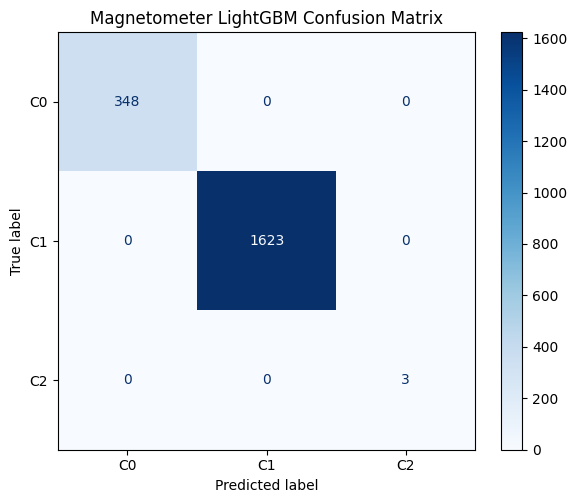

Top features (LightGBM):
mag_dx               1369
mag_x                1179
mag_dz                841
mag_y                 804
mag_dy                777
mag_z                 768
mag_mag_roll_std      435
mag_mag_roll_mean     352
mag_mag               203

Regression metrics for MAG:
  Predict mag_x from ['mag_y', 'mag_z']: MSE=141.779, RMSE=11.9071, R²=0.640169
  Predict mag_y from ['mag_x', 'mag_z']: MSE=94.0549, RMSE=9.69819, R²=0.597107
  Predict mag_z from ['mag_x', 'mag_y']: MSE=47.7314, RMSE=6.90879, R²=0.441352
  Predict mag_mag from ['mag_x', 'mag_y', 'mag_z']: MSE=27.6062, RMSE=5.25416, R²=0.29955
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003765 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 18671, number of used features: 9
[LightGBM] [Info] Start training from score -0.634336
[LightGBM] [Info] Start training from sc

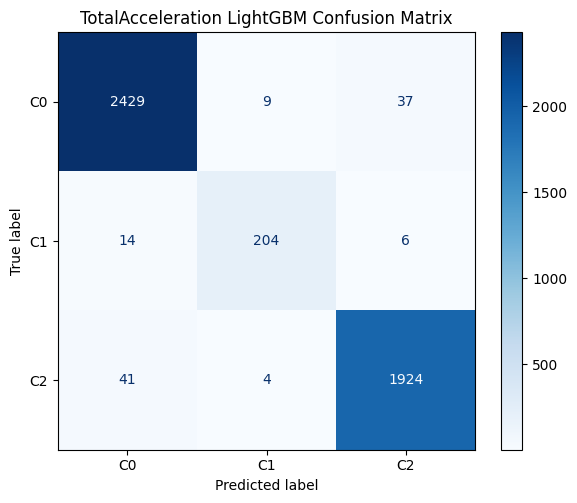

Top features (LightGBM):
totacc_mag              1333
totacc_dz               1333
totacc_dy               1193
totacc_dx               1190
totacc_z                1102
totacc_mag_roll_mean    1031
totacc_mag_roll_std      975
totacc_x                 456
totacc_y                 387

Regression metrics for TOTACC:
  Predict totacc_x from ['totacc_y', 'totacc_z']: MSE=2.14635, RMSE=1.46504, R²=0.00189687
  Predict totacc_y from ['totacc_x', 'totacc_z']: MSE=3.88577, RMSE=1.97123, R²=0.029079
  Predict totacc_z from ['totacc_x', 'totacc_y']: MSE=3.27512, RMSE=1.80973, R²=0.0291413
  Predict totacc_mag from ['totacc_x', 'totacc_y', 'totacc_z']: MSE=0.620932, RMSE=0.787993, R²=0.788481

Saved lightgbm_metrics_summary.csv


In [79]:
print("By using LightGBM")
# Colab cell: Train and evaluate LightGBM per sensor using KMeans labels as supervised targets
# Adds regression metrics (MSE, RMSE, R²) per sensor: per-axis and magnitude regressions.
# Run this cell after uploading Accelerometer.csv, Gyroscope.csv, Magnetometer.csv, TotalAcceleration.csv

# Install LightGBM (run once)
!pip install -q lightgbm

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score)
import lightgbm as lgb

# ---------- User files ----------
acc_file = "Accelerometer.csv"
gyro_file = "Gyroscope.csv"
mag_file = "Magnetometer.csv"
totacc_file = "TotalAcceleration.csv"

# ---------- Utilities (same as before) ----------
def normalize_axes(df, prefix):
    mapping = {}
    for c in df.columns:
        lc = c.strip().lower()
        if lc in ['x','accx','acc_x','accel_x','gyro_x','mag_x','totacc_x']:
            mapping[c] = f"{prefix}_x"
        elif lc in ['y','accy','acc_y','accel_y','gyro_y','mag_y','totacc_y']:
            mapping[c] = f"{prefix}_y"
        elif lc in ['z','accz','acc_z','accel_z','gyro_z','mag_z','totacc_z']:
            mapping[c] = f"{prefix}_z"
        elif 'second' in lc or 'time' in lc:
            mapping[c] = 'seconds_elapsed'
    return df.rename(columns=mapping)

def load_sensor(filename, prefix):
    df = pd.read_csv(filename, low_memory=False)
    df = normalize_axes(df, prefix)
    required = [f"{prefix}_x", f"{prefix}_y", f"{prefix}_z"]
    if not all(c in df.columns for c in required):
        raise ValueError(f"Missing x,y,z for {prefix} in {filename}. Found columns: {df.columns.tolist()}")
    df = df[required + (['seconds_elapsed'] if 'seconds_elapsed' in df.columns else [])].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna(subset=required).reset_index(drop=True)
    return df

def engineer_features(df, prefix, roll_window=10):
    x = df[f"{prefix}_x"]; y = df[f"{prefix}_y"]; z = df[f"{prefix}_z"]
    feat = pd.DataFrame({
        f"{prefix}_x": x, f"{prefix}_y": y, f"{prefix}_z": z,
        f"{prefix}_mag": np.sqrt(x**2 + y**2 + z**2)
    })
    feat[f"{prefix}_mag_roll_mean"] = feat[f"{prefix}_mag"].rolling(window=roll_window, min_periods=1).mean()
    feat[f"{prefix}_mag_roll_std"] = feat[f"{prefix}_mag"].rolling(window=roll_window, min_periods=1).std().fillna(0)
    feat[f"{prefix}_dx"] = x.diff().fillna(0)
    feat[f"{prefix}_dy"] = y.diff().fillna(0)
    feat[f"{prefix}_dz"] = z.diff().fillna(0)
    return feat.fillna(0)

def make_kmeans_labels(X_df, n_clusters=3, random_state=42):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_df)
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = km.fit_predict(Xs)
    return labels, scaler, km

# ---------- Regression metrics helper ----------
def print_regression_metrics(X_df, prefix):
    """
    For sensor prefix (e.g., 'acc'), compute:
      - For each axis: predict axis from the other two (LinearRegression) -> MSE, RMSE, R2
      - Predict magnitude from x,y,z -> MSE, RMSE, R2
    """
    from sklearn.linear_model import LinearRegression
    print(f"\nRegression metrics for {prefix.upper()}:")
    axes = [f"{prefix}_x", f"{prefix}_y", f"{prefix}_z"]
    for axis in axes:
        if axis not in X_df.columns:
            continue
        predictors = [a for a in axes if a != axis and a in X_df.columns]
        if not predictors:
            continue
        X = X_df[predictors].values
        y = X_df[axis].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        reg = LinearRegression().fit(X_train, y_train)
        y_pred = reg.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        print(f"  Predict {axis} from {predictors}: MSE={mse:.6g}, RMSE={rmse:.6g}, R²={r2:.6g}")

    mag_col = [c for c in X_df.columns if f"{prefix}_mag" in c]
    if mag_col:
        mag = X_df[mag_col[0]].values
        predictors = [c for c in X_df.columns if c in axes]
        X = X_df[predictors].values
        X_train, X_test, y_train, y_test = train_test_split(X, mag, test_size=0.2, random_state=42)
        reg = LinearRegression().fit(X_train, y_train)
        y_pred = reg.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        print(f"  Predict {mag_col[0]} from {predictors}: MSE={mse:.6g}, RMSE={rmse:.6g}, R²={r2:.6g}")

# ---------- LightGBM training + evaluation (with regression metrics) ----------
def train_lightgbm(X, y, model_name="Model"):
    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    print(f"\n=== {model_name} LightGBM ===")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Ensure 1D arrays for labels
    y_test_1d = np.asarray(y_test).ravel()
    y_pred_1d = np.asarray(y_pred).ravel()
    labels = np.unique(np.concatenate([y_test_1d, y_pred_1d])).astype(int)

    cm = confusion_matrix(y_test_1d, y_pred_1d, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"C{int(l)}" for l in labels])
    fig, ax = plt.subplots(figsize=(6,5))
    disp.plot(cmap='Blues', ax=ax, colorbar=True)
    ax.set_title(f"{model_name} LightGBM Confusion Matrix")
    plt.tight_layout()
    plt.show()

    try:
        fi = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
        print("Top features (LightGBM):")
        print(fi.head(10).to_string())
    except Exception:
        pass

    # Regression metrics for this sensor's features (per-axis and magnitude)
    first_col = X.columns[0]
    prefix = first_col.split('_')[0]
    print_regression_metrics(X, prefix)

    return {"clf": clf, "cm": cm, "report": classification_report(y_test_1d, y_pred_1d, output_dict=True, zero_division=0)}

# ---------- Run per sensor ----------
print("Loading sensors...")
acc_df = load_sensor(acc_file, "acc")
gyro_df = load_sensor(gyro_file, "gyro")
mag_df = load_sensor(mag_file, "mag")
totacc_df = load_sensor(totacc_file, "totacc")

print("Engineering features...")
acc_X = engineer_features(acc_df, "acc")
gyro_X = engineer_features(gyro_df, "gyro")
mag_X = engineer_features(mag_df, "mag")
totacc_X = engineer_features(totacc_df, "totacc")

results = {}

# Accelerometer
acc_labels, acc_scaler, acc_km = make_kmeans_labels(acc_X, n_clusters=3)
results['acc'] = train_lightgbm(acc_X, acc_labels, model_name="Accelerometer")

# Gyroscope
gyro_labels, gyro_scaler, gyro_km = make_kmeans_labels(gyro_X, n_clusters=3)
results['gyro'] = train_lightgbm(gyro_X, gyro_labels, model_name="Gyroscope")

# Magnetometer
mag_labels, mag_scaler, mag_km = make_kmeans_labels(mag_X, n_clusters=3)
results['mag'] = train_lightgbm(mag_X, mag_labels, model_name="Magnetometer")

# TotalAcceleration
tot_labels, tot_scaler, tot_km = make_kmeans_labels(totacc_X, n_clusters=3)
results['totacc'] = train_lightgbm(totacc_X, tot_labels, model_name="TotalAcceleration")

# Save summary
summary = []
for k,v in results.items():
    rep = v['report']
    summary.append({"sensor": k, "accuracy": rep.get("accuracy", None), "macro avg f1": rep.get("macro avg", {}).get("f1-score", None)})
pd.DataFrame(summary).to_csv("lightgbm_metrics_summary.csv", index=False)
print("\nSaved lightgbm_metrics_summary.csv")


By using CatBoost
Loading sensors...
Engineering features...

=== Accelerometer CatBoost ===
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       113
           1       0.97      0.96      0.97      1059
           2       0.99      0.99      0.99      2522

    accuracy                           0.98      3694
   macro avg       0.97      0.96      0.96      3694
weighted avg       0.98      0.98      0.98      3694



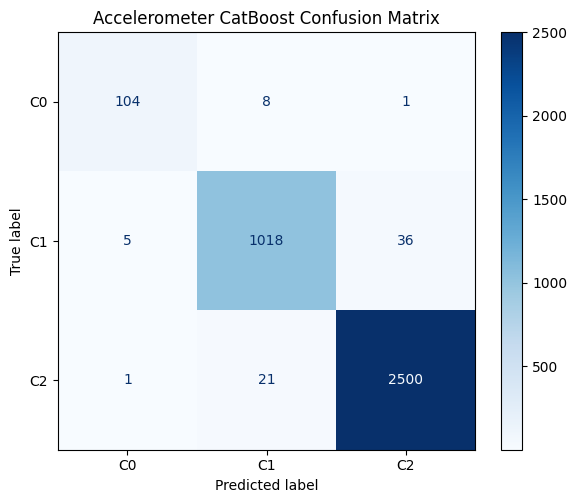

Top features (CatBoost):
acc_dx               18.329899
acc_z                16.986026
acc_dz               16.079791
acc_x                11.475598
acc_mag_roll_std     11.260984
acc_mag_roll_mean     9.386539
acc_dy                7.269476
acc_mag               6.515422
acc_y                 2.696266

Regression metrics for ACC:
  Predict acc_x from ['acc_y', 'acc_z']: MSE=2.05991, RMSE=1.43524, R²=0.0927074
  Predict acc_y from ['acc_x', 'acc_z']: MSE=2.1993, RMSE=1.483, R²=0.0485133
  Predict acc_z from ['acc_x', 'acc_y']: MSE=3.2423, RMSE=1.80064, R²=0.0613376
  Predict acc_mag from ['acc_x', 'acc_y', 'acc_z']: MSE=3.2353, RMSE=1.79869, R²=0.00890913

=== Gyroscope CatBoost ===
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       273
           1       1.00      1.00      1.00      3419
           2       0.60      0.75      0.67         4

    accuracy                           1.00      3696
   macro avg       0.86      0.90   

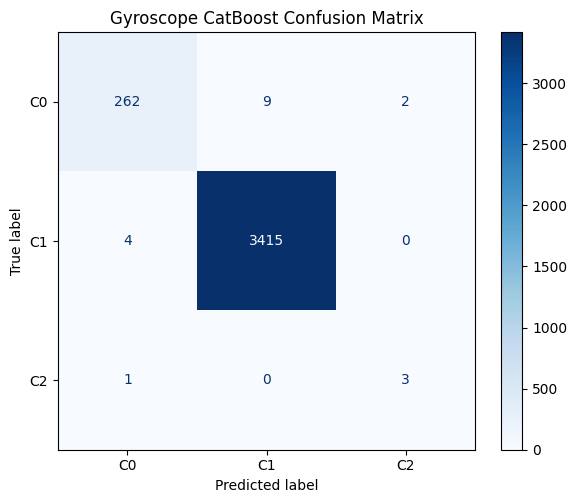

Top features (CatBoost):
gyro_mag_roll_std     26.388381
gyro_mag              24.346320
gyro_mag_roll_mean    20.120384
gyro_z                 7.712055
gyro_x                 5.007961
gyro_dy                4.976271
gyro_y                 4.321392
gyro_dx                4.098445
gyro_dz                3.028791

Regression metrics for GYRO:
  Predict gyro_x from ['gyro_y', 'gyro_z']: MSE=0.06921, RMSE=0.263078, R²=0.0657449
  Predict gyro_y from ['gyro_x', 'gyro_z']: MSE=0.116468, RMSE=0.341274, R²=0.00667448
  Predict gyro_z from ['gyro_x', 'gyro_y']: MSE=0.0405482, RMSE=0.201366, R²=0.0743374
  Predict gyro_mag from ['gyro_x', 'gyro_y', 'gyro_z']: MSE=0.106503, RMSE=0.326348, R²=0.0385409

=== Magnetometer CatBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       348
           1       1.00      1.00      1.00      1623
           2       1.00      1.00      1.00         3

    accuracy                           1.00      19

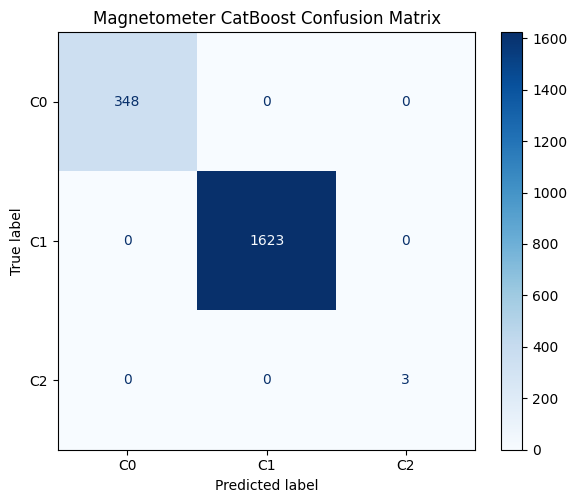

Top features (CatBoost):
mag_x                82.013176
mag_y                 7.441218
mag_z                 3.345881
mag_mag_roll_mean     1.756784
mag_dz                1.305794
mag_mag               1.234383
mag_mag_roll_std      1.038459
mag_dy                0.992960
mag_dx                0.871344

Regression metrics for MAG:
  Predict mag_x from ['mag_y', 'mag_z']: MSE=141.779, RMSE=11.9071, R²=0.640169
  Predict mag_y from ['mag_x', 'mag_z']: MSE=94.0549, RMSE=9.69819, R²=0.597107
  Predict mag_z from ['mag_x', 'mag_y']: MSE=47.7314, RMSE=6.90879, R²=0.441352
  Predict mag_mag from ['mag_x', 'mag_y', 'mag_z']: MSE=27.6062, RMSE=5.25416, R²=0.29955

=== TotalAcceleration CatBoost ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2475
           1       0.95      0.92      0.94       224
           2       0.99      0.99      0.99      1969

    accuracy                           0.98      4668
   macro avg       0.97      

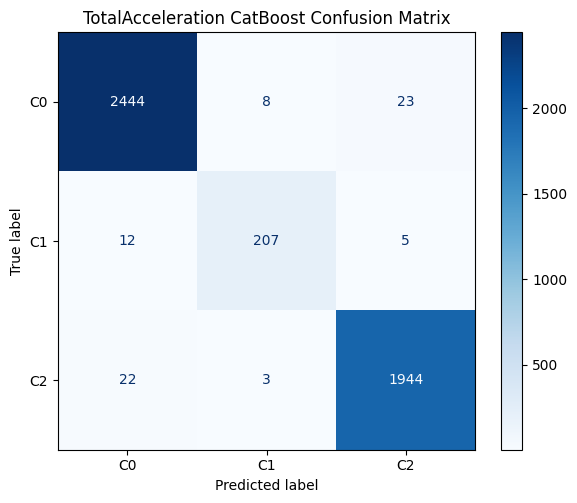

Top features (CatBoost):
totacc_mag              21.615805
totacc_z                19.953165
totacc_dz               15.044975
totacc_dx               10.420849
totacc_mag_roll_std      9.735236
totacc_dy                9.301255
totacc_mag_roll_mean     9.098436
totacc_x                 2.509308
totacc_y                 2.320971

Regression metrics for TOTACC:
  Predict totacc_x from ['totacc_y', 'totacc_z']: MSE=2.14635, RMSE=1.46504, R²=0.00189687
  Predict totacc_y from ['totacc_x', 'totacc_z']: MSE=3.88577, RMSE=1.97123, R²=0.029079
  Predict totacc_z from ['totacc_x', 'totacc_y']: MSE=3.27512, RMSE=1.80973, R²=0.0291413
  Predict totacc_mag from ['totacc_x', 'totacc_y', 'totacc_z']: MSE=0.620932, RMSE=0.787993, R²=0.788481

Saved catboost_metrics_summary.csv


In [80]:
print("By using CatBoost")
# Colab cell: CatBoost per sensor + classification reports, confusion matrices, and regression metrics (MSE, RMSE, R²)
# Run after uploading Accelerometer.csv, Gyroscope.csv, Magnetometer.csv, TotalAcceleration.csv

!pip install -q catboost

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from catboost import CatBoostClassifier

# Filenames
acc_file = "Accelerometer.csv"
gyro_file = "Gyroscope.csv"
mag_file = "Magnetometer.csv"
totacc_file = "TotalAcceleration.csv"

# ---------- Utilities ----------
def normalize_axes(df, prefix):
    mapping = {}
    for c in df.columns:
        lc = c.strip().lower()
        if lc in ['x','accx','acc_x','accel_x','gyro_x','mag_x','totacc_x']:
            mapping[c] = f"{prefix}_x"
        elif lc in ['y','accy','acc_y','accel_y','gyro_y','mag_y','totacc_y']:
            mapping[c] = f"{prefix}_y"
        elif lc in ['z','accz','acc_z','accel_z','gyro_z','mag_z','totacc_z']:
            mapping[c] = f"{prefix}_z"
        elif 'second' in lc or 'time' in lc:
            mapping[c] = 'seconds_elapsed'
    return df.rename(columns=mapping)

def load_sensor(filename, prefix):
    df = pd.read_csv(filename, low_memory=False)
    df = normalize_axes(df, prefix)
    required = [f"{prefix}_x", f"{prefix}_y", f"{prefix}_z"]
    if not all(c in df.columns for c in required):
        raise ValueError(f"Missing x,y,z for {prefix} in {filename}. Found: {df.columns.tolist()}")
    df = df[required + (['seconds_elapsed'] if 'seconds_elapsed' in df.columns else [])].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna(subset=required).reset_index(drop=True)
    return df

def engineer_features(df, prefix, roll_window=10):
    x = df[f"{prefix}_x"]; y = df[f"{prefix}_y"]; z = df[f"{prefix}_z"]
    feat = pd.DataFrame({
        f"{prefix}_x": x, f"{prefix}_y": y, f"{prefix}_z": z,
        f"{prefix}_mag": np.sqrt(x**2 + y**2 + z**2)
    })
    feat[f"{prefix}_mag_roll_mean"] = feat[f"{prefix}_mag"].rolling(window=roll_window, min_periods=1).mean()
    feat[f"{prefix}_mag_roll_std"] = feat[f"{prefix}_mag"].rolling(window=roll_window, min_periods=1).std().fillna(0)
    feat[f"{prefix}_dx"] = x.diff().fillna(0)
    feat[f"{prefix}_dy"] = y.diff().fillna(0)
    feat[f"{prefix}_dz"] = z.diff().fillna(0)
    return feat.fillna(0)

def make_kmeans_labels(X_df, n_clusters=3, random_state=42):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_df)
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = km.fit_predict(Xs)
    return labels, scaler, km

# Regression metrics helper: per-axis and magnitude (LinearRegression)
def print_regression_metrics(X_df, prefix):
    print(f"\nRegression metrics for {prefix.upper()}:")
    axes = [f"{prefix}_x", f"{prefix}_y", f"{prefix}_z"]
    for axis in axes:
        if axis not in X_df.columns:
            continue
        predictors = [a for a in axes if a != axis and a in X_df.columns]
        if not predictors:
            continue
        X = X_df[predictors].values
        y = X_df[axis].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        reg = LinearRegression().fit(X_train, y_train)
        y_pred = reg.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        print(f"  Predict {axis} from {predictors}: MSE={mse:.6g}, RMSE={rmse:.6g}, R²={r2:.6g}")

    mag_col = [c for c in X_df.columns if f"{prefix}_mag" in c]
    if mag_col:
        mag = X_df[mag_col[0]].values
        predictors = [c for c in X_df.columns if c in axes]
        X = X_df[predictors].values
        X_train, X_test, y_train, y_test = train_test_split(X, mag, test_size=0.2, random_state=42)
        reg = LinearRegression().fit(X_train, y_train)
        y_pred = reg.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        print(f"  Predict {mag_col[0]} from {predictors}: MSE={mse:.6g}, RMSE={rmse:.6g}, R²={r2:.6g}")

# ---------- CatBoost training + evaluation (with regression metrics) ----------
def train_catboost(X, y, model_name="Model"):
    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    clf = CatBoostClassifier(verbose=0, random_state=42)
    clf.fit(X_train, y_train)

    # Ensure 1D arrays for comparison and plotting
    y_test_1d = np.asarray(y_test).ravel()
    y_pred = clf.predict(X_test)
    y_pred_1d = np.asarray(y_pred).ravel()

    # Build labels from flattened arrays
    labels = np.unique(np.concatenate([y_test_1d, y_pred_1d]))

    print(f"\n=== {model_name} CatBoost ===")
    print(classification_report(y_test_1d, y_pred_1d, zero_division=0))

    cm = confusion_matrix(y_test_1d, y_pred_1d, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"C{int(l)}" for l in labels])
    fig, ax = plt.subplots(figsize=(6,5))
    disp.plot(cmap='Blues', ax=ax, colorbar=True)
    ax.set_title(f"{model_name} CatBoost Confusion Matrix")
    plt.tight_layout()
    plt.show()

    try:
        fi = pd.Series(clf.get_feature_importance(), index=X.columns).sort_values(ascending=False)
        print("Top features (CatBoost):")
        print(fi.head(10).to_string())
    except Exception:
        pass

    # Regression metrics for this sensor's features (per-axis and magnitude)
    first_col = X.columns[0]
    prefix = first_col.split('_')[0]
    print_regression_metrics(X, prefix)

    return {"clf": clf, "cm": cm, "report": classification_report(y_test_1d, y_pred_1d, output_dict=True, zero_division=0)}

# ---------- Run pipeline ----------
print("Loading sensors...")
acc_df = load_sensor(acc_file, "acc")
gyro_df = load_sensor(gyro_file, "gyro")
mag_df = load_sensor(mag_file, "mag")
totacc_df = load_sensor(totacc_file, "totacc")

print("Engineering features...")
acc_X = engineer_features(acc_df, "acc")
gyro_X = engineer_features(gyro_df, "gyro")
mag_X = engineer_features(mag_df, "mag")
totacc_X = engineer_features(totacc_df, "totacc")

results = {}

# Accelerometer
acc_labels, acc_scaler, acc_km = make_kmeans_labels(acc_X, n_clusters=3)
results['acc'] = train_catboost(acc_X, acc_labels, model_name="Accelerometer")

# Gyroscope
gyro_labels, gyro_scaler, gyro_km = make_kmeans_labels(gyro_X, n_clusters=3)
results['gyro'] = train_catboost(gyro_X, gyro_labels, model_name="Gyroscope")

# Magnetometer
mag_labels, mag_scaler, mag_km = make_kmeans_labels(mag_X, n_clusters=3)
results['mag'] = train_catboost(mag_X, mag_labels, model_name="Magnetometer")

# TotalAcceleration
tot_labels, tot_scaler, tot_km = make_kmeans_labels(totacc_X, n_clusters=3)
results['totacc'] = train_catboost(totacc_X, tot_labels, model_name="TotalAcceleration")

# Save summary
summary = []
for k,v in results.items():
    rep = v['report']
    summary.append({"sensor": k, "accuracy": rep.get("accuracy", None), "macro avg f1": rep.get("macro avg", {}).get("f1-score", None)})
pd.DataFrame(summary).to_csv("catboost_metrics_summary.csv", index=False)
print("\nSaved catboost_metrics_summary.csv")
